# Re-evaluate test set scores

### Setup

In [14]:
import os
import pandas as pd
import math
import itertools

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from datasets import Dataset, load_dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from transformers import pipeline

import torch
from torch.utils.data import DataLoader

from rdkit import Chem
from collections import Counter
from copy import deepcopy

from scipy.special import softmax

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

### Evaluate FART models on test set after alternate standardization


In [15]:
test_cleaned = pd.read_csv("test_alternate_standardization.csv")
test_dataset = Dataset.from_pandas(test_cleaned)

In [16]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(test_dataset['Canonicalized Taste'])
test_dataset = test_dataset.add_column('label', encoded_labels)
label_names = label_encoder.inverse_transform(range(5))

In [17]:
#tokenizer = AutoTokenizer.from_pretrained("FartLabs/FART_Augmented")
model_checkpoint = "seyonec/SMILES_tokenized_PubChem_shard00_160k"  # Edit this line to use a different pretrained model

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
def tokenize_function(examples):
    return tokenizer(examples["Canonicalized SMILES"], padding="max_length", truncation=True, max_length=512)

In [27]:
model = AutoModelForSequenceClassification.from_pretrained("FartLabs/FART_Augmented")
# model = AutoModelForSequenceClassification.from_pretrained("FartLabs/FART_Canonical")

In [28]:
x = test_dataset.map(tokenize_function, batched=True)

cols = ["input_ids", "attention_mask"]
if "token_type_ids" in x.column_names:
    cols.append("token_type_ids")

x.set_format(type="torch", columns=cols)

Map: 100%|██████████| 2237/2237 [00:00<00:00, 13145.86 examples/s]


In [29]:
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
loader = DataLoader(x, batch_size=16, shuffle=False, collate_fn=collator)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
           

In [30]:
all_probs, all_preds = [], []

with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items() if k in cols}
        outputs = model(**batch)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())

In [31]:
probs = torch.cat(all_probs, dim=0).numpy()
pred_labels = torch.cat(all_preds, dim=0).numpy()

### Metrics

In [32]:
true_labels = encoded_labels

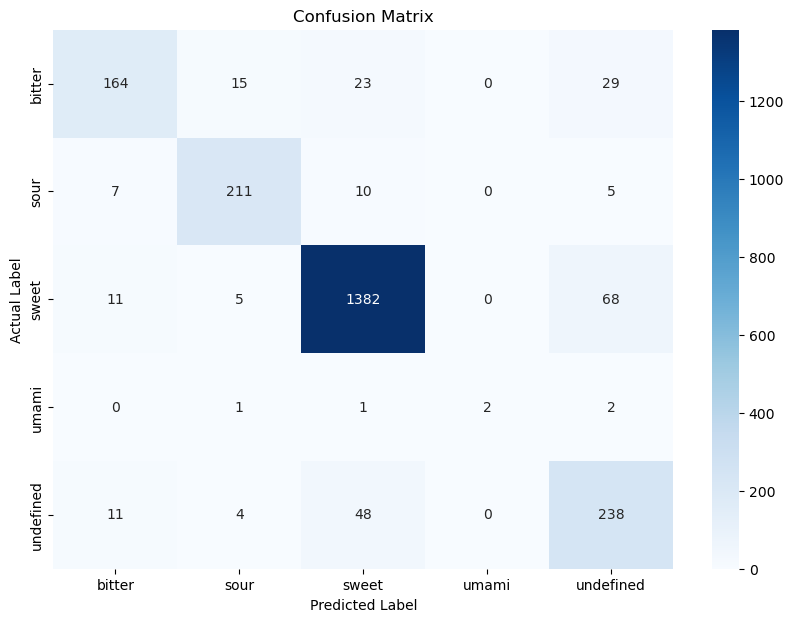

In [33]:
# Create confusion matrix

conf_matrix = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 7))

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=label_names, yticklabels=label_names)

plt.title('Confusion Matrix')

plt.ylabel('Actual Label')

plt.xlabel('Predicted Label')

plt.show()


In [34]:
# Calculate accuracy

accuracy = accuracy_score(true_labels, pred_labels)

print(f"Accuracy: {accuracy:.4f}")



# Calculate precision, recall, and F1 score for each class

precision, recall, f1, support = precision_recall_fscore_support(true_labels, pred_labels)



# Optionally, if you want to calculate the weighted scores as well

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(true_labels, pred_labels, average='macro')

print(f"Weighted Precision: {precision_weighted:.4f}")

print(f"Weighted Recall: {recall_weighted:.4f}")

print(f"Weighted F1 Score: {f1_weighted:.4f}")

class_names = label_encoder.classes_

for i, (p, r, f, s) in enumerate(zip(precision, recall, f1, support)):

    print(f"Class {class_names[i]}:")

    print(f"  Precision: {p:.4f}")

    print(f"  Recall: {r:.4f}")

    print(f"  F1 Score: {f:.4f}")

    print(f"  Support: {s}")

Accuracy: 0.8927
Weighted Precision: 0.8767
Weighted Recall: 0.7365
Weighted F1 Score: 0.7714
Class bitter:
  Precision: 0.8497
  Recall: 0.7100
  F1 Score: 0.7736
  Support: 231
Class sour:
  Precision: 0.8941
  Recall: 0.9056
  F1 Score: 0.8998
  Support: 233
Class sweet:
  Precision: 0.9440
  Recall: 0.9427
  F1 Score: 0.9433
  Support: 1466
Class umami:
  Precision: 1.0000
  Recall: 0.3333
  F1 Score: 0.5000
  Support: 6
Class undefined:
  Precision: 0.6959
  Recall: 0.7907
  F1 Score: 0.7403
  Support: 301


Unweighted AUROC: 0.9742


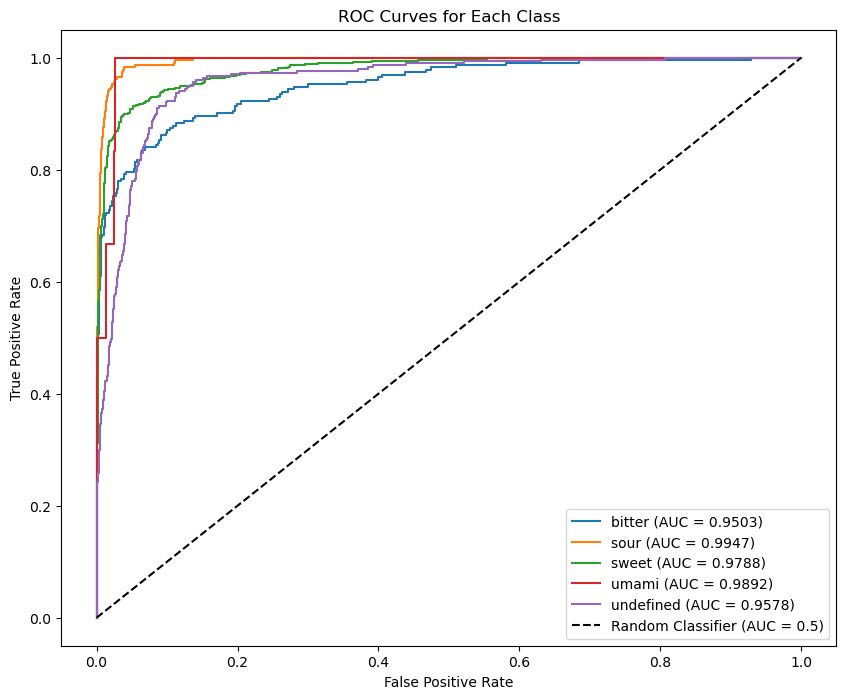

In [35]:
# Plot ROC curves for each class

num_classes = probs.shape[1]

# Binarize the true labels
true_labels_bin = label_binarize(true_labels, classes=np.arange(num_classes))

class_labels = label_encoder.inverse_transform(range(5))

plt.figure(figsize=(10, 8))
auc_scores = []
for i in range(num_classes):
    if np.sum(true_labels_bin[:, i]) > 0:  # Check if the class is in y_true
        auc = roc_auc_score(true_labels_bin[:, i], probs[:, i])
        auc_scores.append(auc)
        fpr, tpr, _ = roc_curve(true_labels_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {auc:.4f})")
    else:
        print(f"{class_labels[i]} not present in true_labels.")

print(f"Unweighted AUROC: {np.mean(auc_scores):.4f}")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Class")
plt.legend(loc="lower right")
# plt.savefig('ROC.pdf')